In [1]:
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import tifffile as tiff
import os, cv2
import albumentations as A
from PIL import Image
import segmentation_models_pytorch as smp

from torch.amp import autocast, GradScaler
from albumentations.pytorch import ToTensorV2

In [2]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [3]:
DATA_DIR = "tiff"

x_train_dir = os.path.join(DATA_DIR, 'train')
y_train_dir = os.path.join(DATA_DIR, 'train_labels')

x_valid_dir = os.path.join(DATA_DIR, 'val')
y_valid_dir = os.path.join(DATA_DIR, 'val_labels')

x_test_dir = os.path.join(DATA_DIR, 'test')
y_test_dir = os.path.join(DATA_DIR, 'test_labels')

In [ ]:
class RoadsDataset:
    def __init__(self, X_path: str, y_path: str, shape: int):
        shape_image = (shape, shape)
        self.X_pathes, self.y_pathes = self.unpack(X_path, y_path)
       
        self.transform = A.Compose([
            A.Resize(*shape_image),
            A.GaussianBlur(blur_limit=(3,7), p=0.2),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=15, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), # type: ignore
            ToTensorV2()
        ])

    def unpack(self, X_path: str, y_path: str):
        X, y = [], []
        for img_path, lbl_path in zip(sorted(os.listdir(X_path)), sorted(os.listdir(y_path))):
            X.append(os.path.join(X_path, img_path))
            y.append(os.path.join(y_path, lbl_path))
        return X, y
    
    def __getitem__(self, key):

        image = np.array(Image.open(self.X_pathes[key]).convert('RGB'))
        label = np.array(Image.open(self.y_pathes[key]).convert('L'))
        
        label[np.all(image == 255, axis=-1)] = 0

        aug = self.transform(image=image, mask=label)

        image_t = aug['image']
        label_t = aug['mask']

        return image_t, (label_t > 0.5).long()

    def __len__(self):
        return len(self.y_pathes)

In [5]:
model = smp.Unet(
    encoder_name="mobilenet_v2",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=3,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=1,                      # model output channels (number of classes in your dataset)
    activation=None
)

train_dataset = RoadsDataset(x_train_dir, y_train_dir, 1024)
test_dataset = RoadsDataset(x_test_dir, y_test_dir, 1024)


train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=8, shuffle=False, pin_memory=True)

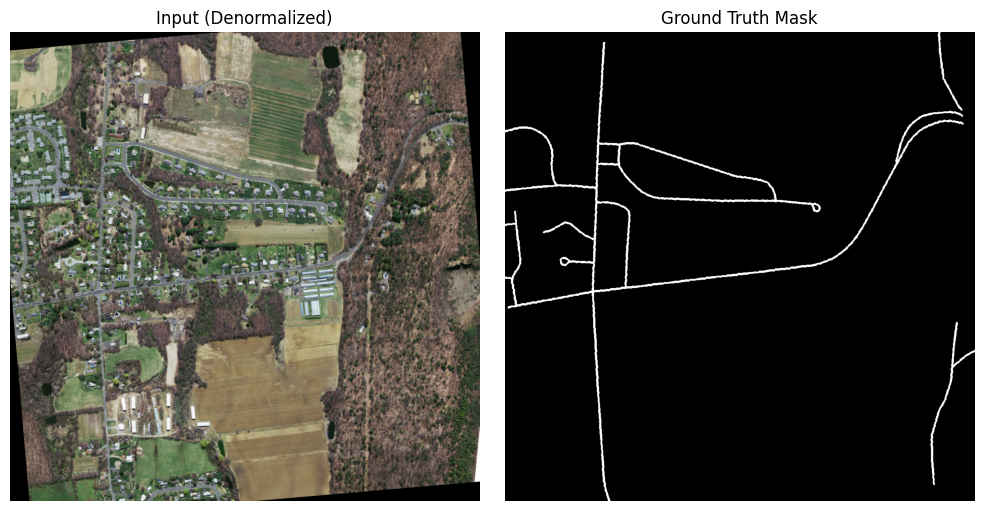

In [6]:
image, mask = train_dataset[2]

# 1. Меняем форму тензора с (C, H, W) на (H, W, C)
image = image.permute(1, 2, 0).cpu().numpy()
mask = mask.cpu().numpy()

# 2. Денормализация изображения (обратный процесс к A.Normalize)
# Mean: [0.485, 0.456, 0.406], Std: [0.229, 0.224, 0.225]
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image * std + mean
image = np.clip(image, 0, 1)  # На случай небольших выбросов после денормализации

# 3. Отрисовка
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Input (Denormalized)")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
opt = torch.optim.AdamW(params=model.parameters(), lr=3e-4, weight_decay=1e-5)

dice_func = smp.losses.DiceLoss(mode='binary')
# bce_func = smp.losses.FocalLoss(mode='binary')
bce_func = torch.nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=5, factor=0.5)

scaler = GradScaler()

In [8]:


def train_step() -> Tuple[float, float, float]:
    model.train()
    running_loss = 0.
    total_tp, total_fp, total_fn = 0, 0, 0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        masks = masks.unsqueeze(1)
        masks_long = masks.long()
        masks_float = masks.float()
        bs = images.size(0)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.

        

        with autocast(device_type="cuda"):
            output = model(images)
            loss = dice_func(torch.sigmoid(output), masks_float) + bce_func(output, masks_float)
        

        tp, fp, fn, tn = smp.metrics.get_stats(torch.sigmoid(output), masks_long, mode='binary', threshold=.5)

        total_tp += tp.sum().item()
        total_fp += fp.sum().item()
        total_fn += fn.sum().item()

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        scaler.scale(loss).backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        scaler.step(opt)
        scaler.update()
        
        # Накапливаем статистику.
        running_loss += loss.item() * images.size(0)
    
        
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        global_iou = total_tp / (total_tp + total_fp + total_fn + 1e-7)
        global_dice = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-7)
        avg_loss = running_loss / len(train_loader.dataset)
    return global_iou, global_dice, avg_loss


def test_step() -> Tuple[float, float, float]:
    model.eval()

    total_tp, total_fp, total_fn = 0, 0, 0
    total_loss = 0.0

    running_loss = 0.
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            masks = masks.unsqueeze(1)
            masks_long = masks.long()
            masks_float = masks.float()
            bs = images.size(0)


            with autocast(device_type="cuda"):
                output = model(images)
                loss = dice_func(torch.sigmoid(output), masks_float) + bce_func(output, masks_float)

            tp, fp, fn, tn = smp.metrics.get_stats(torch.sigmoid(output), masks_long, mode='binary', threshold=.5)

            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_loss += loss.item() * images.size(0)
            
            running_loss += loss.item() * bs

    global_iou = total_tp / (total_tp + total_fp + total_fn + 1e-7)
    global_dice = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-7)
    avg_loss = total_loss / len(test_loader.dataset)
    
    return global_iou, global_dice, avg_loss

In [9]:
train_losses = []
valid_losses = []
iouses, dices, bceses, accses = [], [], [], []

In [10]:
epochs = 50
model.to(device)

best_iou = -1

for epoch in (pbar := tqdm(range(epochs))):
    train_iou, train_dice, train_loss = train_step()
    av_iou, av_dice, av_loss  = test_step()
    
    train_losses.append(train_loss)
    valid_losses.append(av_loss)

    iouses.append(av_iou)
    dices.append(av_dice)

    model.train()
    scheduler.step(av_iou)

    pbar.set_description(f'Avg. train/valid loss/ IoU/ Dice: {train_loss:.4f}/{av_loss:.4f}/{av_iou:.4f}/{av_dice:.4f}')
    print(f'  train : iou: {train_iou:.4f}, dice: {train_dice:.4f}')
    if av_iou > best_iou:
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), 'best_model.pth')
            best_iou = av_iou
            print(f'  Сохранена модель {epoch+1} эпохи')

Avg. train/valid loss/ IoU/ Dice: 1.2407/1.0710/0.3396/0.5070:   2%|▏         | 1/50 [04:53<3:59:48, 293.65s/it]

  train : iou: 0.0799, dice: 0.1479
  Сохранена модель 1 эпохи


Avg. train/valid loss/ IoU/ Dice: 1.0375/1.0042/0.4690/0.6386:   4%|▍         | 2/50 [09:41<3:52:09, 290.20s/it]

  train : iou: 0.3983, dice: 0.5697
  Сохранена модель 2 эпохи


Avg. train/valid loss/ IoU/ Dice: 1.0035/0.9911/0.4958/0.6629:   6%|▌         | 3/50 [14:25<3:45:09, 287.43s/it]

...

  train : iou: 0.6045, dice: 0.7535


Avg. train/valid loss/ IoU/ Dice: 0.9531/0.9541/0.5983/0.7487:  98%|█████████▊| 49/50 [3:56:32<04:49, 289.13s/it]

  train : iou: 0.6052, dice: 0.7540


Avg. train/valid loss/ IoU/ Dice: 0.9527/0.9548/0.5949/0.7460: 100%|██████████| 50/50 [4:01:21<00:00, 289.63s/it]

  train : iou: 0.6069, dice: 0.7554


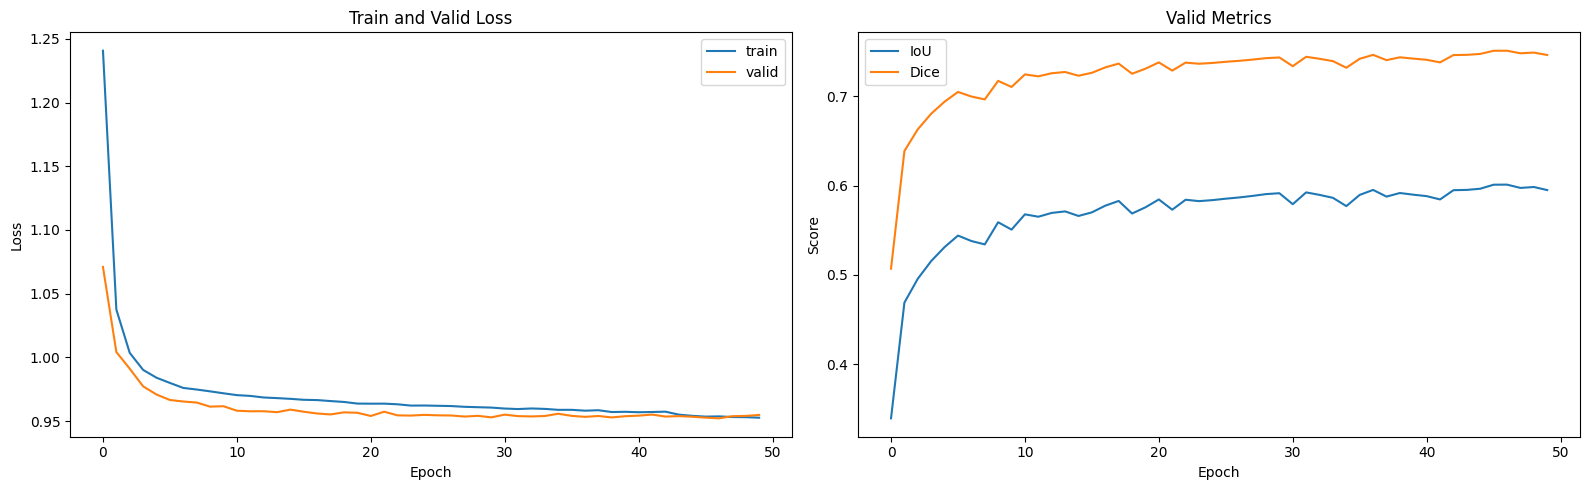

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].set_title('Train and Valid Loss')
ax[0].plot(train_losses, label='train')
ax[0].plot(valid_losses, label='valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].set_title('Valid Metrics')
ax[1].plot(iouses, label='IoU')
ax[1].plot(dices, label='Dice')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Score')
ax[1].legend()

plt.tight_layout()

Train LoSS: 0.9537

Test LoSS:  0.9522

Test IoU:   0.6010

Test DiCE:  0.7508

Train IoU:  0.6018

Train DiCE: 0.7514

In [12]:
checkpoint = torch.load('best_model.pth', map_location='cpu') 
model.load_state_dict(checkpoint)

# 3. Переносим на устройство и ставим режим оценки
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

idx = 0

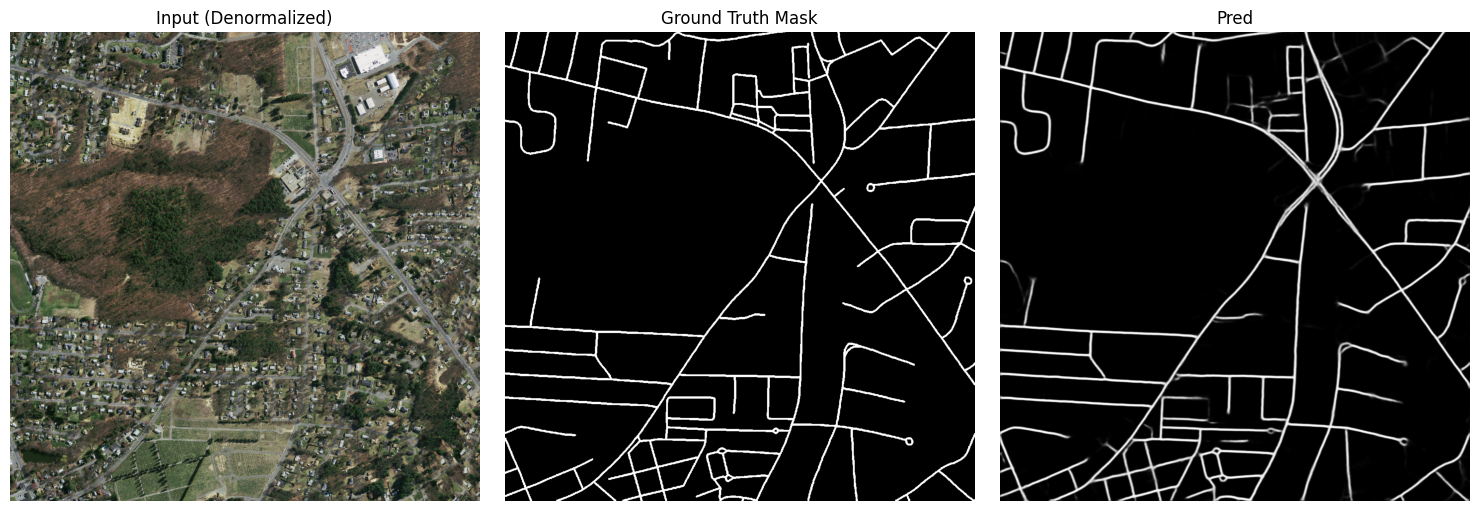

In [15]:

image, mask = test_dataset[idx]
idx = idx + 1
image = image.unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(image)

pred = torch.sigmoid(pred)
pred = pred.squeeze().cpu().numpy()
mask = mask.cpu().numpy()

image_denorm = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_denorm = image_denorm * std + mean
image_denorm = np.clip(image_denorm, 0, 1)

# 3. Отрисовка
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Input (Denormalized)")
plt.imshow(image_denorm)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Pred")
plt.imshow(pred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()